This is run on `chinook`. 

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import dask
from matplotlib import pyplot as plt

In [ ]:
testyears_1 = ['2021', '2022']
testyears_final = list(map(str, range(1993, 2024)))
months = [11, 12, 1, 2]
resolution = '4'
filepattern_1 = "era5_wrf_dscale_{resolution}km".format(resolution=resolution) 

In [ ]:
testyears_final

['1993',
 '1994',
 '1995',
 '1996',
 '1997',
 '1998',
 '1999',
 '2000',
 '2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012',
 '2013',
 '2014',
 '2015',
 '2016',
 '2017',
 '2018',
 '2019',
 '2020',
 '2021',
 '2022',
 '2023']

In [ ]:
datadir = Path(f"/import/beegfs/CMIP6/wrf_era5/{resolution.zfill(2)}km/")

## Loop through year / month files and aggregate

In [ ]:
def rain_not_snow(dspth, thresh_rain=0.1, thresh_total=0.2):
    with xr.open_dataset(dspth) as ds:
        rain_nc = ds.rainnc
        rain_c = ds.rainc
        ac_snow = ds.acsnow
        rain_not_snow = ((rain_nc + rain_c) - ac_snow) > thresh_rain
        precip = (rain_nc + rain_c) > thresh_total
        significant_rain = rain_not_snow & precip
    return significant_rain

In [ ]:
thresh = 0.1
thresh_total = 0.2

with xr.open_dataset(datadir / f"2021/era5_wrf_dscale_{resolution}km_2021-12-29.nc") as ds:
    rain = ((ds.rainnc + ds.rainc) - ds.acsnow) > thresh
    precip = (ds.rainnc + ds.rainc) > thresh_total
    significant_rain = rain & precip

# for ii in range(24):
#     rain_not_snow.isel(Time=ii).plot()
#     plt.show()

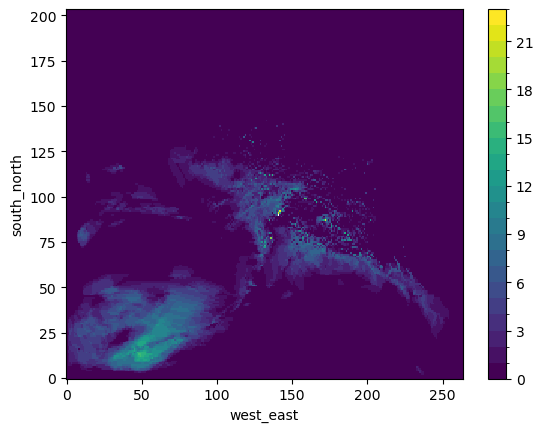

In [ ]:
significant_rain.sum(dim='Time').plot(levels=25)

In [ ]:
# %%timeit 
loopyr = testyears_1[:1]
loopmth = months
time = pd.date_range(testyears_1[0], freq="ME", periods=len(loopyr)*12, name='time')
time = time.where(time.month.isin(loopmth)).dropna()

collect = []
for tm in time:
    yr = str(tm.year)
    mth = str(tm.month).zfill(2)
    print(yr, mth)
    fpths =  sorted(list((datadir / f"{yr}").glob(f"{filepattern_1}_{yr}-{mth}*.nc")))
    
    acc = [rain_not_snow(pth).sum(dim='Time') for pth in fpths]
    collect.append(sum(acc))

monthly_winterrain = xr.concat(collect, dim=time)

2021 01
2021 02
2021 11
2021 12


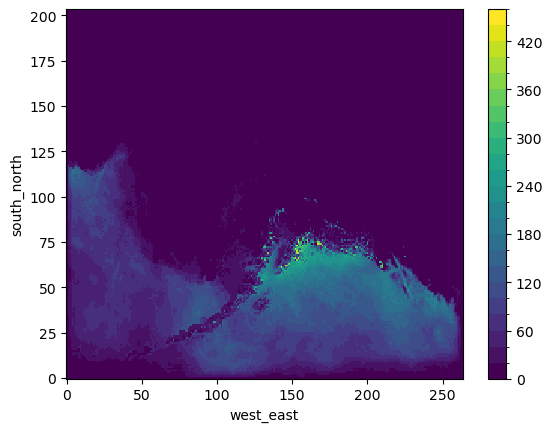

In [ ]:
collect[0].plot(levels=25)

In [ ]:
years = testyears_final
years

['1993',
 '1994',
 '1995',
 '1996',
 '1997',
 '1998',
 '1999',
 '2000',
 '2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012',
 '2013',
 '2014',
 '2015',
 '2016',
 '2017',
 '2018',
 '2019',
 '2020',
 '2021',
 '2022',
 '2023']

In [ ]:
from joblib import delayed, Parallel

time = pd.date_range(years[0], freq="ME", periods=len(years)*12, name='time')
time = time.where(time.month.isin(loopmth)).dropna()
time = time.where(time > f"{time[0].year}-10-31").dropna()
time = time.where(time < f"{time[-1].year}-03-01").dropna()

collect = []
for tm in time:
    yr = str(tm.year)
    mth = str(tm.month).zfill(2)
    print(yr, mth)
    fpths =  sorted(list((datadir / f"{yr}").glob(f"{filepattern_1}_{yr}-{mth}*.nc")))

    results = Parallel(n_jobs=5)(
                        delayed(rain_not_snow)(pth) for pth in fpths)
    
    collect.append(sum([results.sum(dim='Time') for results in results]))

monthly_winterrain = xr.concat(collect, dim=time)

1993 11
1993 12
1994 01
1994 02
1994 11
1994 12
1995 01
1995 02
1995 11
1995 12
1996 01
1996 02
1996 11
1996 12
1997 01
1997 02
1997 11
1997 12
1998 01
1998 02
1998 11
1998 12
1999 01
1999 02
1999 11
1999 12
2000 01
2000 02
2000 11
2000 12
2001 01
2001 02
2001 11
2001 12
2002 01
2002 02
2002 11
2002 12
2003 01
2003 02
2003 11
2003 12
2004 01
2004 02
2004 11
2004 12
2005 01
2005 02
2005 11
2005 12
2006 01
2006 02
2006 11
2006 12
2007 01
2007 02
2007 11
2007 12
2008 01
2008 02
2008 11
2008 12
2009 01
2009 02
2009 11
2009 12
2010 01
2010 02
2010 11
2010 12
2011 01
2011 02
2011 11
2011 12
2012 01
2012 02
2012 11
2012 12
2013 01
2013 02
2013 11
2013 12
2014 01
2014 02
2014 11
2014 12
2015 01
2015 02
2015 11
2015 12
2016 01
2016 02
2016 11
2016 12
2017 01
2017 02
2017 11
2017 12
2018 01
2018 02
2018 11
2018 12
2019 01
2019 02
2019 11
2019 12
2020 01
2020 02
2020 11
2020 12
2021 01
2021 02
2021 11
2021 12
2022 01
2022 02
2022 11
2022 12
2023 01
2023 02


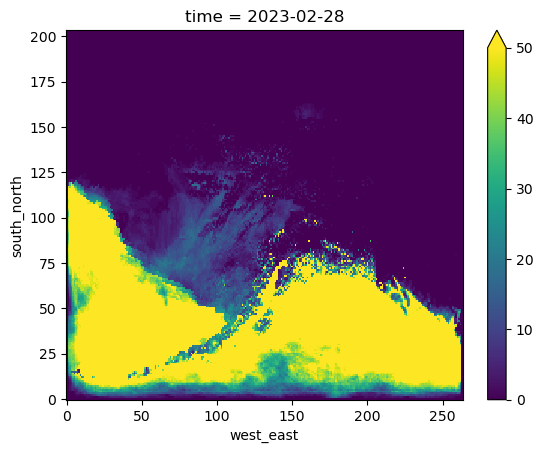

In [ ]:
monthly_winterrain.isel(time=-1).plot(vmax=50)

In [ ]:

monthly_winterrain.name = "rain_not_snow_hours"
monthly_winterrain.attrs['long_name'] = "Number of hours with significant rain and no snow"
monthly_winterrain.attrs['description'] = f"Number of hours where rain minus snow exceeds {thresh} mm and total rain exceeds {thresh_total} mm"
monthly_winterrain.attrs['units'] = "hours"

In [ ]:
outdir =  Path().absolute().parent / "evaluation/working"
outfp = outdir / f"monthly_winterrain_{resolution}km.nc"
monthly_winterrain.to_netcdf(outfp, encoding={'rain_not_snow_hours': {"zlib": True, "complevel": 5}})

## aggregate to winterly data

In [ ]:
outdir = Path().absolute().parent / "evaluation/working"
infp = outdir / f"monthly_winterrain_{resolution}km.nc"
monthly_winterrain = xr.open_dataarray(infp, decode_times={"rain_not_snow_hours": False})
# monthly_winterrain = xr.open_dataarray(infp)
monthly_winterrain

<xarray.DataArray 'rain_not_snow_hours' (time: 120, south_north: 204,
                                         west_east: 264)> Size: 52MB
[6462720 values with dtype=int64]
Coordinates:
    XLONG    (south_north, west_east) float32 215kB ...
    XLAT     (south_north, west_east) float32 215kB ...
  * time     (time) datetime64[ns] 960B 1993-11-30 1993-12-31 ... 2023-02-28
Dimensions without coordinates: south_north, west_east
Attributes:
    long_name:    Number of hours with significant rain and no snow
    description:  Number of hours where rain minus snow exceeds 0.1 mm and to...
    units:        hours

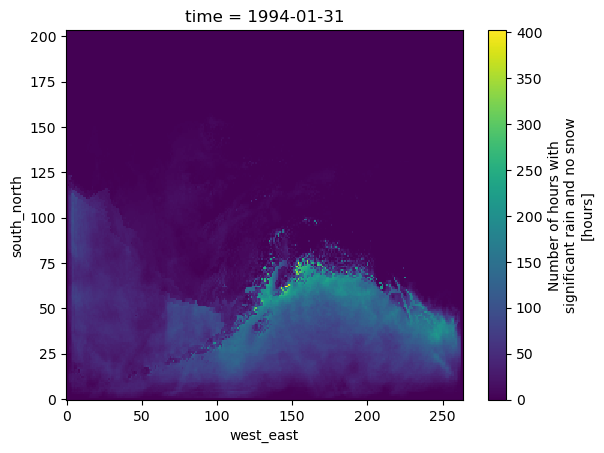

In [ ]:
monthly_winterrain.isel(time=2).plot()

In [ ]:
time

DatetimeIndex(['1993-11-30', '1993-12-31', '1994-01-31', '1994-02-28',
               '1994-11-30', '1994-12-31', '1995-01-31', '1995-02-28',
               '1995-11-30', '1995-12-31',
               ...
               '2021-01-31', '2021-02-28', '2021-11-30', '2021-12-31',
               '2022-01-31', '2022-02-28', '2022-11-30', '2022-12-31',
               '2023-01-31', '2023-02-28'],
              dtype='datetime64[ns]', name='time', length=120, freq=None)

In [ ]:
annual_winterrain = monthly_winterrain.coarsen(time=4).sum()
newtime = pd.date_range(start=time[1], freq="YE", periods=len(testyears_final)-1, name='time')
annual_winterrain['time'] = newtime
annual_winterrain

<xarray.DataArray 'rain_not_snow_hours' (time: 30, south_north: 204,
                                         west_east: 264)> Size: 13MB
array([[[ 0,  0,  0, ...,  0,  0,  0],
        [ 0, 19, 21, ...,  5,  5,  0],
        [ 0, 25, 36, ...,  5,  5,  0],
        ...,
        [ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0]],

       [[ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  2, 17, ...,  0,  0,  0],
        [ 0,  6, 20, ...,  7,  2,  0],
        ...,
        [ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0]],

       [[ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  3,  6, ...,  2,  0,  0],
        [ 0,  8, 11, ...,  7,  0,  0],
        ...,
...
        ...,
        [ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0]],

       [[ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  5, 11, ...,  6,  6,  0],
        [ 0, 17, 34, ..., 18, 12,  0],
        ...,
        [ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0]],

       [[ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  3,  3, ...,  1,  1,  0],
        [ 0,  7, 10, ..., 14, 12,  0],
        ...,
        [ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0]]])
Coordinates:
    XLONG    (south_north, west_east) float32 215kB ...
    XLAT     (south_north, west_east) float32 215kB ...
  * time     (time) datetime64[ns] 240B 1993-12-31 1994-12-31 ... 2022-12-31
Dimensions without coordinates: south_north, west_east
Attributes:
    long_name:    Number of hours with significant rain and no snow
    description:  Number of hours where rain minus snow exceeds 0.1 mm and to...
    units:        hours

In [ ]:
len(newtime)

30

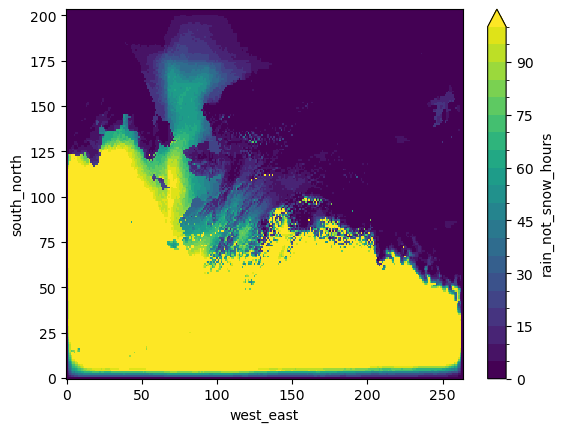

In [ ]:
annual_winterrain.mean(dim='time').plot(vmax=100, levels=21)

In [ ]:
outdir =  Path().absolute().parent / "evaluation/working"
outfp = outdir / f"annual_winterrain_{resolution}km.nc"
annual_winterrain.to_netcdf(outfp, encoding={'rain_not_snow_hours': {"zlib": True, "complevel": 5}})

In [ ]:
outfp = outdir / f"winterrain_climo_{resolution}km.nc"
annual_winterrain.mean(dim='time').to_netcdf(outfp, encoding={'rain_not_snow_hours': {"zlib": True, "complevel": 5}})


## Plotting

In [ ]:
import cartopy.crs as ccrs
import cartopy.feature as cf
from matplotlib.cm import get_cmap
from matplotlib import pyplot as plt

In [ ]:
projection = ccrs.Stereographic(
    central_longitude=-152.0, # central_latitude=64.0, 
    true_scale_latitude=64.0, central_latitude=64.0)

/tmp/ipykernel_1630903/3081670720.py:1: UserWarning: "true_scale_latitude" parameter is only used for polar stereographic projections. Consider the use of "scale_factor" instead.
  projection = ccrs.Stereographic(


In [ ]:
if resolution == '12':
    extent = [-175, -135, 54, 73.5]
elif resolution == '4':
    extent = [-165.2, -139.3, 55.4, 71.6]

/import/SNAP/cwaigl/dyndowntools/.pixi/envs/default/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


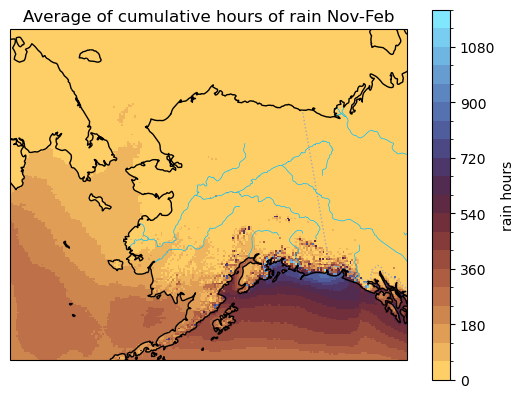

In [ ]:
ax = plt.axes(projection=projection)
annual_winterrain.mean(dim='time').plot(
    levels=21, cbar_kwargs={'label': 'rain hours'},
    transform=ccrs.PlateCarree(),
    # vmax = 50,
    ax=ax,
    cmap='managua',
    x="XLONG", y="XLAT",
)
ax.coastlines()
ax.add_feature(cf.BORDERS, linestyle=':', color='darkgrey')
ax.add_feature(cf.RIVERS, linewidth=.5, color='deepskyblue')
plt.title(f"Average of cumulative hours of rain Nov-Feb")
# ax.set_extent([-164.35, -140.3, 55.5, 71.3])
ax.set_extent(extent)

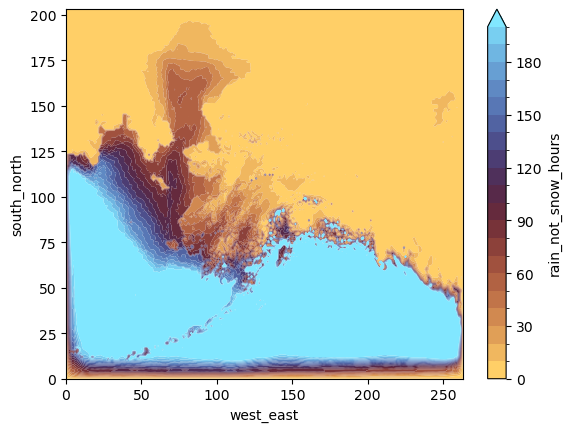

In [ ]:
# ax = plt.axes(projection=projection)
annual_winterrain.mean(dim='time').plot.contourf(
    # levels=21, cbar_kwargs={'label': 'rain hours'},
    levels = 21,
    # transform=ccrs.PlateCarree(),
    antialiased=True,
    vmax = 200,
    # norm='log',
    # ax=ax,
    cmap='managua',
    # x="XLONG", y="XLAT",
)
# ax.coastlines()
# ax.add_feature(cf.BORDERS, linestyle=':', color='darkgrey')
# ax.add_feature(cf.RIVERS, linewidth=.5, color='deepskyblue')
# plt.title(f"Average of cumulative hours of rain Nov-Feb")
# # ax.set_extent([-164.35, -140.3, 55.5, 71.3])
ax.set_extent(extent)
plt.show()

/import/SNAP/cwaigl/dyndowntools/.pixi/envs/default/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


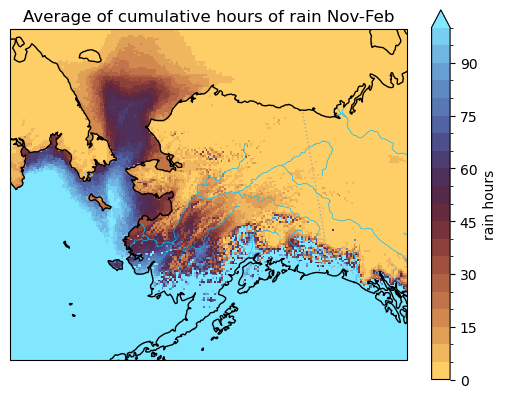

In [ ]:
ax = plt.axes(projection=projection)
annual_winterrain.mean(dim='time').plot(
    levels=21, cbar_kwargs={'label': 'rain hours'},
    transform=ccrs.PlateCarree(),
    vmax = 100,
    ax=ax,
    cmap='managua',
    x="XLONG", y="XLAT",
)
ax.coastlines()
ax.add_feature(cf.BORDERS, linestyle=':', color='darkgrey')
ax.add_feature(cf.RIVERS, linewidth=.5, color='deepskyblue')
plt.title(f"Average of cumulative hours of rain Nov-Feb")
# ax.set_extent([-164.35, -140.3, 55.5, 71.3])
ax.set_extent(extent)

/import/SNAP/cwaigl/dyndowntools/.pixi/envs/default/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


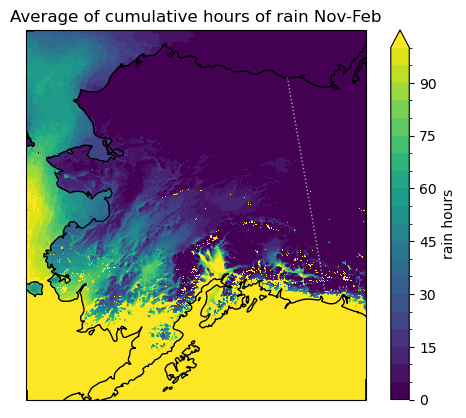

In [ ]:
ax = plt.axes(projection=projection)
annual_winterrain.mean(dim='time').plot(
    levels=21, cbar_kwargs={'label': 'rain hours'},
    transform=ccrs.PlateCarree(),
    vmax = 100,
    ax=ax,
    # cmap='PuBu',
    x="XLONG", y="XLAT",
)
ax.coastlines()
ax.add_feature(cf.BORDERS, linestyle=':', color='darkgrey')
# ax.add_feature(cf.RIVERS, linewidth=.5, color='deepskyblue')
plt.title(f"Average of cumulative hours of rain Nov-Feb")
# ax.set_extent([-164.35, -140.3, 55.5, 71.3])
ax.set_extent([-165.2, -139.3, 55.4, 71.6])

## Trends (linear, Theil-Sen)

In [ ]:
from scipy.stats import theilslopes, linregress
import pymannkendall as mk

In [ ]:
resolution = '4' 
outdir = Path().absolute().parent / "evaluation/working"
infp = outdir / f"annual_winterrain_{resolution}km.nc"
annual_winterrain = xr.open_dataarray(infp, decode_times={"rain_not_snow_hours": False}).astype(float)
# monthly_winterrain = xr.open_dataarray(infp, decode_times={"rain_not_snow_hours": False}).astype(float)
# monthly_winterrain = xr.open_dataarray(infp)
annual_winterrain

<xarray.DataArray 'rain_not_snow_hours' (time: 30, south_north: 450,
                                         west_east: 420)> Size: 45MB
array([[[  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0., 224., 224., ..., 302., 307.,   0.],
        [  0., 224., 217., ..., 313., 310.,   0.],
        ...,
        [  0.,  25.,  28., ...,   0.,   0.,   0.],
        [  0.,  26.,  26., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.]],

       [[  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0., 189., 192., ..., 273., 271.,   0.],
        [  0., 190., 192., ..., 274., 279.,   0.],
        ...,
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.]],

       [[  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0., 128., 129., ..., 283., 290.,   0.],
        [  0., 133., 132., ..., 287., 287.,   0.],
        ...,
...
        ...,
        [  0.,  62.,  57., ...,   1.,   1.,   0.],
        [  0.,  59.,  58., ...,   1.,   1.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.]],

       [[  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0., 247., 253., ..., 327., 320.,   0.],
        [  0., 241., 246., ..., 327., 318.,   0.],
        ...,
        [  0.,   1.,   2., ...,   0.,   0.,   0.],
        [  0.,   2.,   2., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.]],

       [[  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0., 258., 264., ..., 352., 354.,   0.],
        [  0., 263., 264., ..., 364., 357.,   0.],
        ...,
        [  0.,  56.,  57., ...,   1.,   1.,   0.],
        [  0.,  58.,  57., ...,   0.,   1.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.]]])
Coordinates:
    XLONG    (south_north, west_east) float32 756kB ...
    XLAT     (south_north, west_east) float32 756kB ...
  * time     (time) datetime64[ns] 240B 1993-12-31 1994-12-31 ... 2022-12-31
Dimensions without coordinates: south_north, west_east
Attributes:
    long_name:    Number of hours with significant rain and no snow
    description:  Number of hours where rain minus snow exceeds 0.1 mm and to...
    units:        hours

### Fixing metadata 

In [ ]:
resolution = '12'

In [ ]:
annual_winterrainDS = xr.open_dataset(outdir / f"annual_winterrain_{resolution}km.nc", 
                                      decode_times={"rain_not_snow_hours": False})
monthly_winterrainDS = xr.open_dataset(outdir / f"monthly_winterrain_{resolution}km.nc", 
                                      decode_times={"rain_not_snow_hours": False})

In [ ]:
annual_winterrainDS.attrs['Conventions'] = 'CF-1.7'
annual_winterrainDS['XLAT'].attrs['units'] = 'degrees_north'
annual_winterrainDS['XLONG'].attrs['units'] = 'degrees_east'
annual_winterrainDS['XLONG'].attrs['standard_name'] = 'longitude'
annual_winterrainDS['XLONG'].attrs['long_name'] = 'longitude'
annual_winterrainDS['XLAT'].attrs['standard_name'] = 'latitude'
annual_winterrainDS['XLAT'].attrs['long_name'] = 'latitude' 
monthly_winterrainDS.attrs['Conventions'] = 'CF-1.7'
monthly_winterrainDS['XLAT'].attrs['units'] = 'degrees_north'
monthly_winterrainDS['XLONG'].attrs['units'] = 'degrees_east'
monthly_winterrainDS['XLONG'].attrs['standard_name'] = 'longitude'
monthly_winterrainDS['XLONG'].attrs['long_name'] = 'longitude'
monthly_winterrainDS['XLAT'].attrs['standard_name'] = 'latitude'
monthly_winterrainDS['XLAT'].attrs['long_name'] = 'latitude' 

In [ ]:
annual_winterrainDS

<xarray.Dataset> Size: 13MB
Dimensions:              (south_north: 204, west_east: 264, time: 30)
Coordinates:
    XLONG                (south_north, west_east) float32 215kB ...
    XLAT                 (south_north, west_east) float32 215kB ...
  * time                 (time) datetime64[ns] 240B 1993-12-31 ... 2022-12-31
Dimensions without coordinates: south_north, west_east
Data variables:
    rain_not_snow_hours  (time, south_north, west_east) int64 13MB ...
Attributes:
    Conventions:  CF-1.7

In [ ]:
outdir =  Path().absolute().parent / "evaluation/working"

In [ ]:
outfp = outdir / f"winterrain_climo_{resolution}km_cf.nc"
annual_winterrainDS.mean(dim='time').to_netcdf(outfp, encoding={'rain_not_snow_hours': {"zlib": True, "complevel": 5}})

In [ ]:
outfp = outdir / f"annual_winterrain_{resolution}km_cf.nc"
annual_winterrainDS.to_netcdf(outfp, encoding={'rain_not_snow_hours': {"zlib": True, "complevel": 5}})

In [ ]:
outfp = outdir / f"monthly_winterrain_{resolution}km_cf.nc"
monthly_winterrainDS.to_netcdf(outfp, encoding={'rain_not_snow_hours': {"zlib": True, "complevel": 5}})

## Theil-Sen / Mann-Kendall

In [ ]:
def apply_teil(y, x=None):
    return theilslopes(y, x)[0]
def theil_significance(y, x=None):
    slope, intercept, lower, upper = theilslopes(y, x)

    return (np.sign(lower) == np.sign(upper))
def apply_mk_slope(data):
    if np.isnan(data).all():
        return np.nan
    return mk.original_test(data)[7]
def apply_mk_boolean(data):
    if np.isnan(data).all():
        return np.nan
    return mk.original_test(data)[1]
def apply_mk_significance(data):
    if np.isnan(data).all():
        return np.nan
    return mk.original_test(data)[2]

In [ ]:
testdata = annual_winterrain.isel(south_north=100, west_east=100).values
apply_mk_boolean(testdata)

False

In [ ]:
trend1 = xr.apply_ufunc(
    apply_teil,
    annual_winterrain,
    # np.arange(annual_winterrain.sizes['time']),
    # input_core_dims=[['time'], ['time']],
    input_core_dims=[['time']],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[float],
)

In [ ]:
trend = xr.apply_ufunc(
    apply_mk_slope,
    annual_winterrain,
    input_core_dims=[['time']],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[float],
)

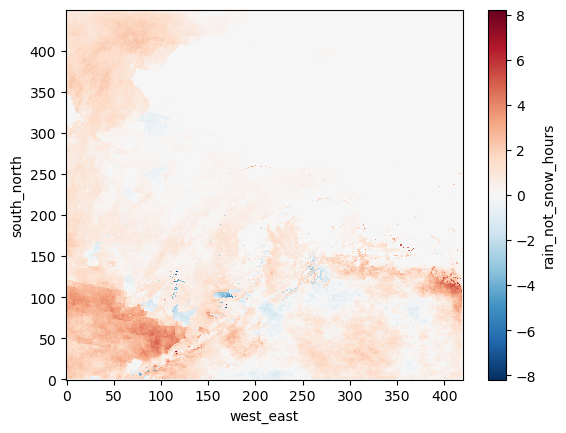

In [ ]:
trend.plot()

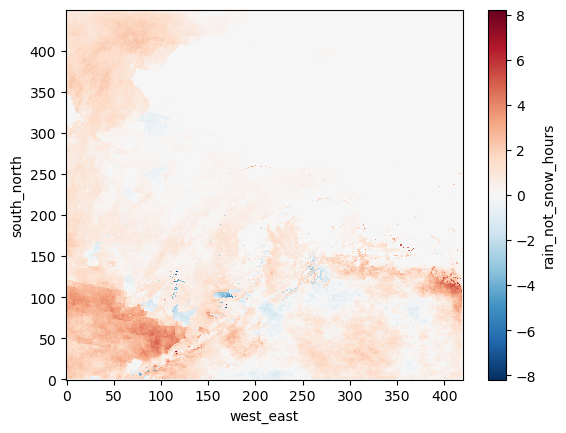

In [ ]:
trend1.plot()

In [ ]:
pvalue = xr.apply_ufunc(
    apply_mk_significance,
    annual_winterrain,
    # np.arange(annual_winterrain.sizes['time']),
    input_core_dims=[['time']],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[float],
)

In [ ]:
trend_exists = xr.apply_ufunc(
    apply_mk_boolean,
    annual_winterrain,
    # np.arange(annual_winterrain.sizes['time']),
    input_core_dims=[['time']],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[bool],
)

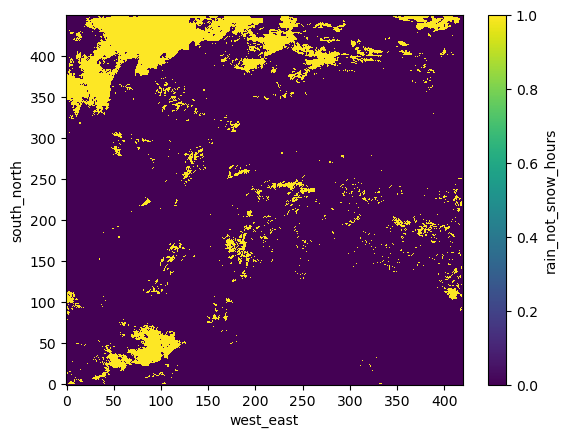

In [ ]:
trend_exists.plot()

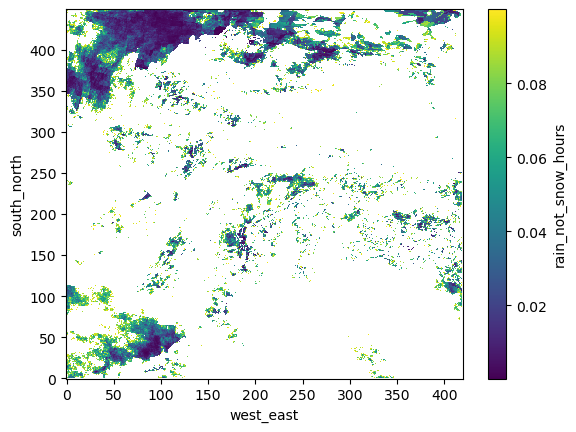

In [ ]:
pvalue.where(pvalue < 0.1).plot()

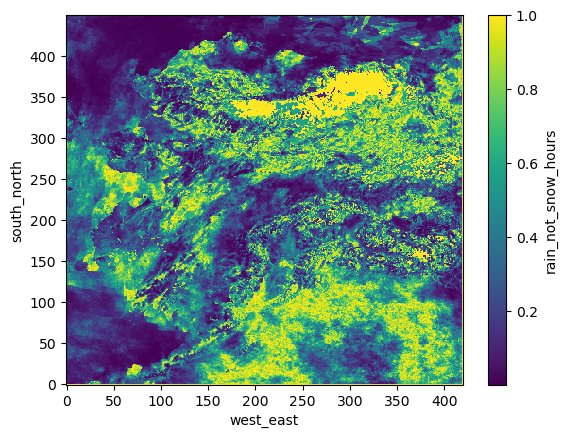

In [ ]:
pvalue.plot()

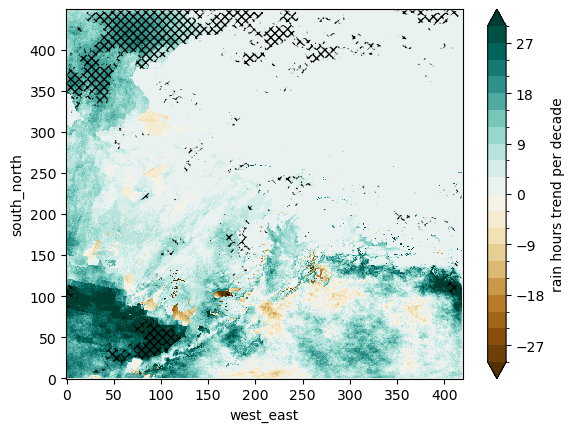

In [ ]:
fig, ax = plt.subplots()
(10*trend).plot(
    levels=21, vmax=30, vmin=-30, cmap='BrBG', ax=ax,
    cbar_kwargs={'label': 'rain hours trend per decade'})
trend_exists.where(trend_exists).plot.contourf(
    colors='none', add_colorbar=False,hatches=['xxxx', None], levels=[0.5, 1.5], ax=ax)

/import/SNAP/cwaigl/dyndowntools/.pixi/envs/default/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


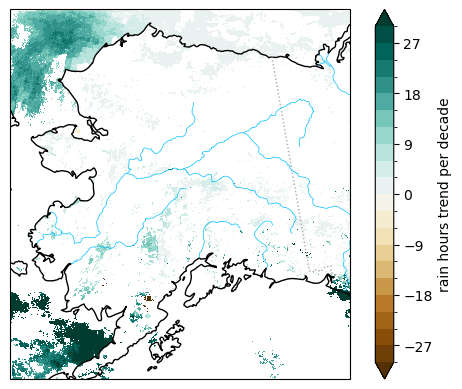

In [ ]:
ax = plt.axes(projection=projection)
(10*trend).where(pvalue < 0.1).plot(
    levels=21, vmax=30, vmin=-30, cmap='BrBG', ax=ax,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'rain hours trend per decade'},
    x="XLONG", y="XLAT",)
# significance.where(significance).plot.contourf(
#     transform=ccrs.PlateCarree(),
#     colors='none', add_colorbar=False,hatches=['..', None], levels=[0.5, 1.5], ax=ax)
ax.coastlines()
ax.add_feature(cf.BORDERS, linestyle=':', color='darkgrey')
ax.add_feature(cf.RIVERS, linewidth=.5, color='deepskyblue')
ax.set_extent([-165.2, -139.3, 55.4, 71.6])

/import/SNAP/cwaigl/dyndowntools/.pixi/envs/default/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


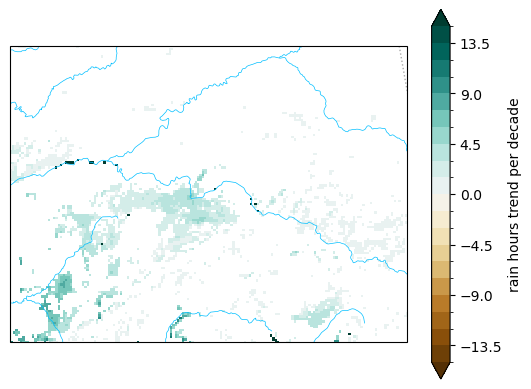

In [ ]:
ax = plt.axes(projection=projection)
(10*trend).where(pvalue < 0.1).plot(
    levels=21, vmax=15, vmin=-15, cmap='BrBG', ax=ax,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'rain hours trend per decade'},
    x="XLONG", y="XLAT",)
# significance.where(significance).plot.contourf(
#     transform=ccrs.PlateCarree(),
#     colors='none', add_colorbar=False,hatches=['..', None], levels=[0.5, 1.5], ax=ax)
ax.coastlines()
ax.add_feature(cf.BORDERS, linestyle=':', color='darkgrey')
ax.add_feature(cf.RIVERS, linewidth=.5, color='deepskyblue')
ax.set_extent([-155.2, -142.3, 62.4, 66.6])

In [ ]:
trend.to_netcdf(outdir / f"trend_winterrain_{resolution}km.nc")
pvalue.to_netcdf(outdir / f"pvalue_winterrain_{resolution}km.nc")
trend_exists.to_netcdf(outdir / f"trend_exists_winterrain_{resolution}km.nc")